# A/B Testing a Marketing Campaign — Control vs. Test

Two Facebook ad campaigns ran for the same 30 days in August 2019, each pushing
visitors down the same funnel: **impression → reach → website click → search →
view content → add to cart → purchase**. This notebook compares the *Control*
and *Test* campaigns end to end — funnel by funnel, metric by metric — and checks
which differences are big enough, and consistent enough, to act on.

The notebook is fully self-contained: it loads `data/control_group.csv` and
`data/test_group.csv` (shipped alongside it) and runs top to bottom with no
external dependencies.

**Contents**
1. [Load & clean the data](#load)
2. [Funnel metrics](#metrics)
3. [Descriptive comparison](#describe)
4. [Daily trends](#trends)
5. [The funnel, side by side](#funnel)
6. [Is the difference real? (hypothesis tests)](#tests)
7. [Spend vs. results](#spend)
8. [Conclusion & recommendation](#conclusion)


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#444444",
    "axes.grid": True,
    "grid.color": "#e6e6e6",
    "grid.linewidth": 0.8,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

CONTROL_COLOR = "#3b82f6"     # blue
TEST_COLOR = "#f97316"        # orange
GOOD_COLOR = "#16a34a"        # green
BAD_COLOR = "#dc2626"         # red

pd.set_option("display.precision", 3)
%matplotlib inline

## 1. Load & clean the data <a id="load"></a>

Each file has one row per day, with `Campaign Name`, `Date`, ad `Spend`, and counts for
every stage of the funnel. The files use `;` as a separator, and dates are in
`day.month.year` format.


In [2]:
control = pd.read_csv("data/control_group.csv", sep=";")
test = pd.read_csv("data/test_group.csv", sep=";")

for df in (control, test):
    df["Date"] = pd.to_datetime(df["Date"], format="%d.%m.%Y")
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

control.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,2019-08-05,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Missing values per column:")
print(pd.concat([control.isnull().sum().rename("control"),
                  test.isnull().sum().rename("test")], axis=1))
control.loc[control.isnull().any(axis=1)]

Missing values per column:
                     control  test
Campaign Name              0     0
Date                       0     0
Spend [USD]                0     0
# of Impressions           1     0
Reach                      1     0
# of Website Clicks        1     0
# of Searches              1     0
# of View Content          1     0
# of Add to Cart           1     0
# of Purchase              1     0


,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
4,Control Campaign,2019-08-05,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


One day (August 5th) in the control group has no recorded activity at all — most
likely the ad simply wasn't served that day rather than truly "zero engagement," but
since we have no way to tell the difference, we fill it with 0 and flag it. Because a
day with 0 impressions would turn every rate metric (clicks/impressions, etc.) into an
undefined `0/0`, we exclude that single day from the *rate-based* comparisons in
Section 6 while still keeping it in the raw daily totals and trend charts.


In [4]:
count_cols = ["# of Impressions", "Reach", "# of Website Clicks", "# of Searches",
              "# of View Content", "# of Add to Cart", "# of Purchase"]
control[count_cols] = control[count_cols].fillna(0)

control["Campaign"] = "Control"
test["Campaign"] = "Test"
data = pd.concat([control, test], ignore_index=True)
data.rename(columns={"Spend [USD]": "Spend"}, inplace=True)
data.shape

(60, 11)

## 2. Funnel metrics <a id="metrics"></a>

Raw counts aren't directly comparable if one campaign got more impressions than the
other, so we derive rate metrics at each step of the funnel, plus two cost metrics tying
everything back to ad spend.


In [5]:
valid = data["# of Impressions"] > 0  # excludes the blank control day

data["CTR"] = np.nan                                   # clicks / impressions
data["Search_Rate"] = np.nan                            # searches / clicks
data["View_Rate"] = np.nan                              # view content / searches
data["Cart_Rate"] = np.nan                               # add to cart / view content
data["Checkout_Rate"] = np.nan                           # purchase / add to cart
data["Overall_Conversion"] = np.nan                      # purchase / impressions
data["CPC"] = np.nan                                     # spend / click
data["CPA"] = np.nan                                     # spend / purchase (cost per acquisition)

data.loc[valid, "CTR"] = data.loc[valid, "# of Website Clicks"] / data.loc[valid, "# of Impressions"]
data.loc[valid, "Search_Rate"] = data.loc[valid, "# of Searches"] / data.loc[valid, "# of Website Clicks"]
data.loc[valid, "View_Rate"] = data.loc[valid, "# of View Content"] / data.loc[valid, "# of Searches"]
data.loc[valid, "Cart_Rate"] = data.loc[valid, "# of Add to Cart"] / data.loc[valid, "# of View Content"]
data.loc[valid, "Checkout_Rate"] = data.loc[valid, "# of Purchase"] / data.loc[valid, "# of Add to Cart"]
data.loc[valid, "Overall_Conversion"] = data.loc[valid, "# of Purchase"] / data.loc[valid, "# of Impressions"]
data.loc[valid, "CPC"] = data.loc[valid, "Spend"] / data.loc[valid, "# of Website Clicks"]
data.loc[valid, "CPA"] = data.loc[valid, "Spend"] / data.loc[valid, "# of Purchase"]

data[["Date", "Campaign", "CTR", "Overall_Conversion", "CPA"]].head()

,Date,Campaign,CTR,Overall_Conversion,CPA
0,2019-08-01,Control,0.085,0.007,3.689
1,2019-08-02,Control,0.067,0.004,3.438
2,2019-08-03,Control,0.049,0.003,6.298
3,2019-08-04,Control,0.042,0.005,5.706
4,2019-08-05,Control,NaN,NaN,NaN


## 3. Descriptive comparison <a id="describe"></a>


In [6]:
summary_cols = ["Spend", "# of Impressions", "# of Website Clicks", "# of Purchase",
                "CTR", "Overall_Conversion", "CPC", "CPA"]
summary = data.groupby("Campaign")[summary_cols].mean()
summary.loc["Test − Control"] = summary.loc["Test"] - summary.loc["Control"]
summary

,Spend,# of Impressions,# of Website Clicks,# of Purchase,CTR,Overall_Conversion,CPC,CPA
Campaign,,,,,,,,
Control,2288.433,105907.767,5143.433,505.367,0.051,0.005,0.495,5.052
Test,2563.067,74584.800,6032.333,521.233,0.102,0.008,0.469,5.900
Test − Control,274.633,-31322.967,888.900,15.867,0.051,0.003,-0.026,0.847


At a glance, the Test campaign reached noticeably **fewer** people (lower impressions
and reach) for a slightly higher spend — but it also has a much higher click-through
rate, so it still generated *more* clicks than Control from that smaller audience.
Whether that pays off further down the funnel is what the rest of this notebook checks.


## 4. Daily trends <a id="trends"></a>


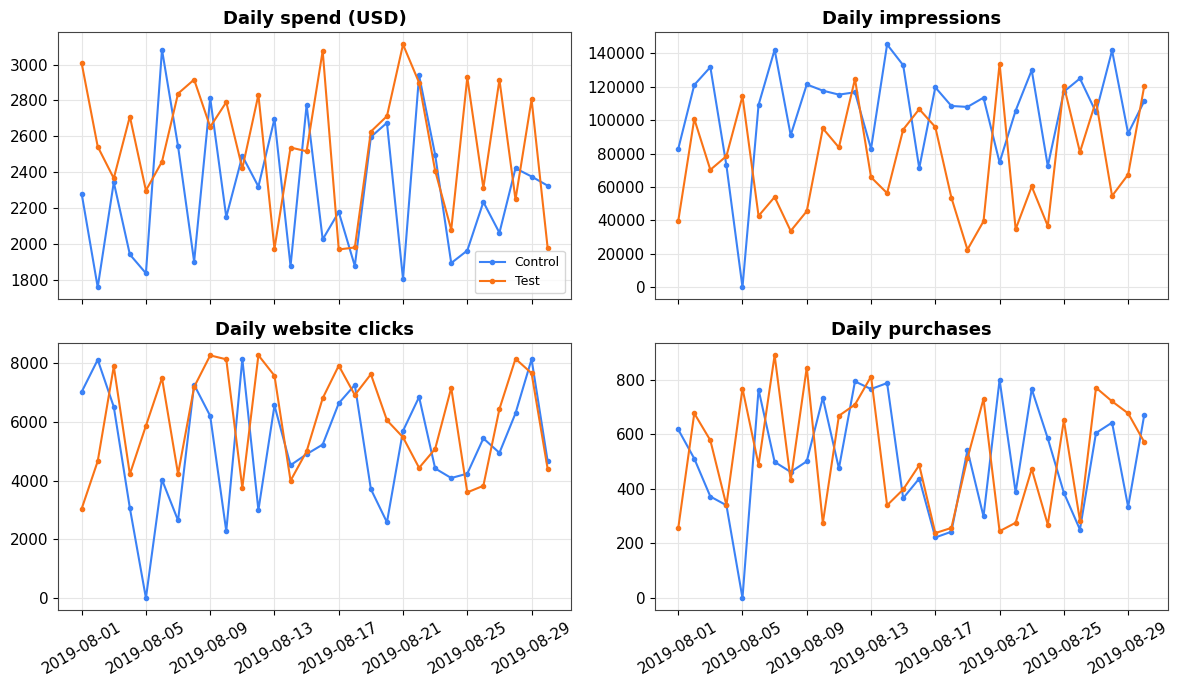

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
metrics_to_plot = ["Spend", "# of Impressions", "# of Website Clicks", "# of Purchase"]
titles = ["Daily spend (USD)", "Daily impressions", "Daily website clicks", "Daily purchases"]

for ax, col, title in zip(axes.flat, metrics_to_plot, titles):
    for name, color in [("Control", CONTROL_COLOR), ("Test", TEST_COLOR)]:
        sub = data[data["Campaign"] == name]
        ax.plot(sub["Date"], sub[col], label=name, color=color, marker="o", ms=3)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)

axes[0, 0].legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5. The funnel, side by side <a id="funnel"></a>

Summing each stage across all 30 days shows where the two campaigns' visitors drop off.


In [8]:
funnel_stages = ["# of Impressions", "Reach", "# of Website Clicks", "# of Searches",
                  "# of View Content", "# of Add to Cart", "# of Purchase"]
funnel_labels = ["Impressions", "Reach", "Website Clicks", "Searches",
                  "View Content", "Add to Cart", "Purchase"]

funnel_totals = data.groupby("Campaign")[funnel_stages].sum().T
funnel_totals.index = funnel_labels
funnel_totals

Campaign,Control,Test
Impressions,3.177e+06,2.238e+06
Reach,2.577e+06,1.605e+06
Website Clicks,1.543e+05,1.810e+05
Searches,6.442e+04,7.257e+04
View Content,5.637e+04,5.574e+04
Add to Cart,3.770e+04,2.645e+04
Purchase,1.516e+04,1.564e+04


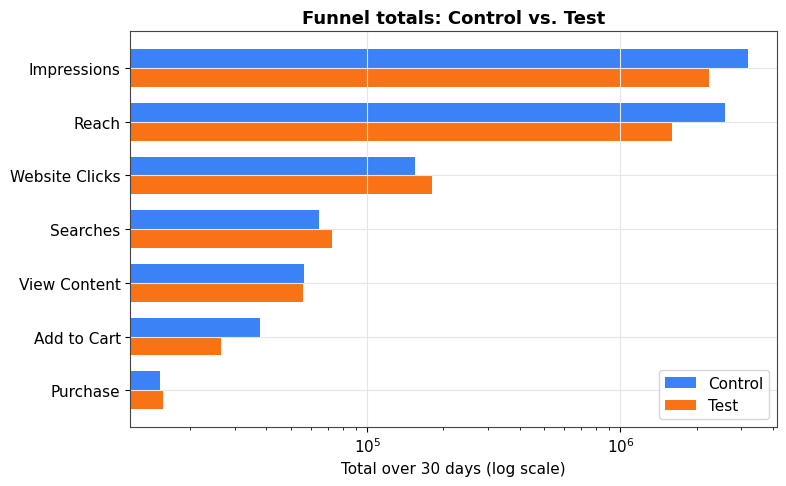

Stage-to-stage conversion (of the previous stage):


,Control,Test
Impressions,100.0%,100.0%
Reach,81.1%,71.7%
Website Clicks,6.0%,11.3%
Searches,41.7%,40.1%
View Content,87.5%,76.8%
Add to Cart,66.9%,47.4%
Purchase,40.2%,59.1%


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(funnel_labels))[::-1]
bar_h = 0.35

ax.barh(y + bar_h / 2, funnel_totals["Control"], height=bar_h, color=CONTROL_COLOR, label="Control")
ax.barh(y - bar_h / 2, funnel_totals["Test"], height=bar_h, color=TEST_COLOR, label="Test")

ax.set_xscale("log")
ax.set_yticks(y)
ax.set_yticklabels(funnel_labels)
ax.set_xlabel("Total over 30 days (log scale)")
ax.set_title("Funnel totals: Control vs. Test")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Stage-to-stage conversion (of the previous stage):")
conv = pd.DataFrame({
    camp: [funnel_totals[camp].iloc[i] / funnel_totals[camp].iloc[i - 1] if i > 0 else 1.0
           for i in range(len(funnel_labels))]
    for camp in ["Control", "Test"]
}, index=funnel_labels)
conv.style.format("{:.1%}")

The picture is mixed, not uniformly better or worse: Test converts clicks into
searches at about the same rate as Control, then **loses more people** at the
view-content and add-to-cart steps, but **wins them back** at the final step —
of everyone who put something in their cart, a clearly larger share of Test's visitors
went on to buy. Section 6 checks which of these gaps are statistically real.


## 6. Is the difference real? (hypothesis tests) <a id="tests"></a>

For each daily rate metric, we run a **Welch's t-test** (two independent samples,
unequal variance assumed) comparing the 29 valid days of Control against the 30 days of
Test, along with the 95% confidence interval for the difference in means. With only
~30 daily observations per group this is a fairly small sample, so treat borderline
results with appropriate caution.


In [10]:
def compare_metric(data, col, alpha=0.05):
    c = data.loc[data["Campaign"] == "Control", col].dropna()
    t = data.loc[data["Campaign"] == "Test", col].dropna()

    diff = t.mean() - c.mean()
    t_stat, p_value = stats.ttest_ind(t, c, equal_var=False)

    se = np.sqrt(t.var(ddof=1) / len(t) + c.var(ddof=1) / len(c))
    df_welch = (t.var(ddof=1) / len(t) + c.var(ddof=1) / len(c)) ** 2 / (
        (t.var(ddof=1) / len(t)) ** 2 / (len(t) - 1) + (c.var(ddof=1) / len(c)) ** 2 / (len(c) - 1)
    )
    t_crit = stats.t.ppf(1 - alpha / 2, df_welch)
    ci_low, ci_high = diff - t_crit * se, diff + t_crit * se

    return {
        "metric": col, "control_mean": c.mean(), "test_mean": t.mean(),
        "diff": diff, "pct_change": diff / c.mean() * 100,
        "ci_low": ci_low, "ci_high": ci_high,
        "p_value": p_value, "significant": p_value < alpha,
    }

metrics_to_test = ["CTR", "Search_Rate", "View_Rate", "Cart_Rate", "Checkout_Rate",
                    "Overall_Conversion", "CPA"]
results = pd.DataFrame([compare_metric(data, m) for m in metrics_to_test]).set_index("metric")
results

,control_mean,test_mean,diff,pct_change,ci_low,ci_high,p_value,significant
metric,,,,,,,,
CTR,0.051,0.102,0.051,100.991,0.025,0.078,3.388e-04,True
Search_Rate,0.441,0.437,-0.004,-0.870,-0.092,0.084,9.308e-01,False
View_Rate,0.873,0.756,-0.117,-13.396,-0.184,-0.050,1.158e-03,True
Cart_Rate,0.778,0.515,-0.263,-33.780,-0.441,-0.084,4.778e-03,True
Checkout_Rate,0.457,0.618,0.161,35.166,0.043,0.278,8.443e-03,True
Overall_Conversion,0.005,0.008,0.003,68.476,0.001,0.006,2.004e-03,True
CPA,5.052,5.900,0.847,16.769,-0.446,2.140,1.946e-01,False


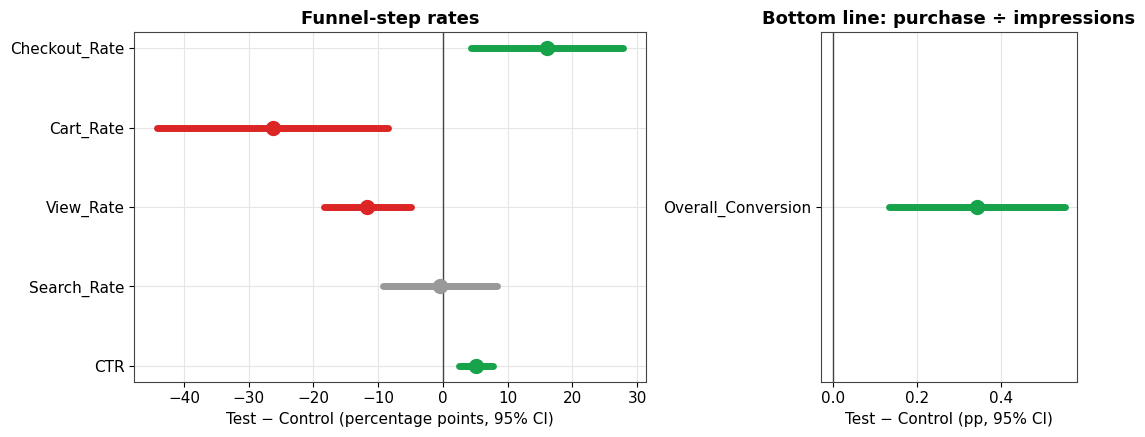

CPA — Control: $5.05/purchase, Test: $5.90/purchase (p=0.195, not significant)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), gridspec_kw={"width_ratios": [2, 1]})

funnel_step_metrics = ["CTR", "Search_Rate", "View_Rate", "Cart_Rate", "Checkout_Rate"]
ax = axes[0]
for i, name in enumerate(funnel_step_metrics):
    row = results.loc[name]
    color = GOOD_COLOR if row["significant"] and row["diff"] > 0 else \
            (BAD_COLOR if row["significant"] and row["diff"] < 0 else "#999999")
    ax.plot([row["ci_low"] * 100, row["ci_high"] * 100], [i, i], color=color, lw=5, solid_capstyle="round")
    ax.scatter([row["diff"] * 100], [i], color=color, s=100, zorder=3)
ax.axvline(0, color="#444444", lw=1)
ax.set_yticks(range(len(funnel_step_metrics)))
ax.set_yticklabels(funnel_step_metrics)
ax.set_xlabel("Test − Control (percentage points, 95% CI)")
ax.set_title("Funnel-step rates")

ax = axes[1]
row = results.loc["Overall_Conversion"]
color = GOOD_COLOR if row["significant"] and row["diff"] > 0 else \
        (BAD_COLOR if row["significant"] and row["diff"] < 0 else "#999999")
ax.plot([row["ci_low"] * 100, row["ci_high"] * 100], [0, 0], color=color, lw=5, solid_capstyle="round")
ax.scatter([row["diff"] * 100], [0], color=color, s=100, zorder=3)
ax.axvline(0, color="#444444", lw=1)
ax.set_yticks([0])
ax.set_yticklabels(["Overall_Conversion"])
ax.set_xlabel("Test − Control (pp, 95% CI)")
ax.set_title("Bottom line: purchase ÷ impressions")

plt.tight_layout()
plt.show()

print(f"CPA — Control: ${results.loc['CPA', 'control_mean']:.2f}/purchase, "
      f"Test: ${results.loc['CPA', 'test_mean']:.2f}/purchase "
      f"(p={results.loc['CPA', 'p_value']:.3f}, "
      f"{'significant' if results.loc['CPA', 'significant'] else 'not significant'})")

Reading the chart: bars that don't cross the vertical zero line are statistically
significant at the 5% level — which turns out to be nearly all of them:

- **Click-through rate** is about double for Test (10.2% vs. 5.1%) — a big, clearly
  significant jump.
- **View-content rate** and **cart rate** are both significantly *lower* for Test —
  proportionally more of its searchers bail out before adding anything to the cart.
- **Checkout rate** (purchase, given something's in the cart) is significantly *higher*
  for Test — of the people who make it that far, more of them buy.
- **Overall conversion** (purchase ÷ impressions), the bottom-line number, is
  significantly higher for Test: roughly 0.8% vs. 0.5%, a large relative jump even
  though it's small in absolute terms.
- **Cost per purchase** trends higher for Test but the difference is *not* statistically
  significant at this sample size — there isn't good evidence Test is more expensive per
  sale, just that it isn't clearly cheaper either.

So Test leaks more people in the middle of the funnel, but wins decisively on the two
steps that matter most for getting a click to become a sale, and that combination comes
out ahead on the metric that matters most: purchases per impression.


## 7. Spend vs. results <a id="spend"></a>

Does spending more on a given day actually buy more purchases, for either campaign?


Control: correlation(spend, purchases) = 0.04
Test: correlation(spend, purchases) = 0.03


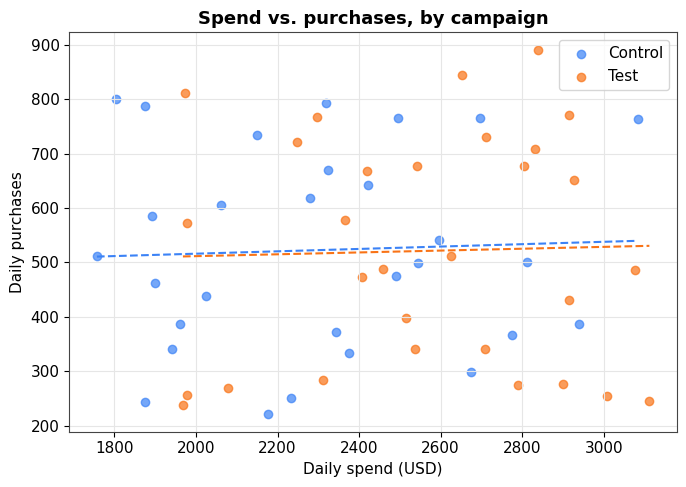

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, color in [("Control", CONTROL_COLOR), ("Test", TEST_COLOR)]:
    sub = data[(data["Campaign"] == name) & valid]
    ax.scatter(sub["Spend"], sub["# of Purchase"], color=color, alpha=0.7, label=name)
    m, b = np.polyfit(sub["Spend"], sub["# of Purchase"], 1)
    xs = np.linspace(sub["Spend"].min(), sub["Spend"].max(), 50)
    ax.plot(xs, m * xs + b, color=color, ls="--", lw=1.5)
    r = np.corrcoef(sub["Spend"], sub["# of Purchase"])[0, 1]
    print(f"{name}: correlation(spend, purchases) = {r:.2f}")

ax.set_xlabel("Daily spend (USD)")
ax.set_ylabel("Daily purchases")
ax.set_title("Spend vs. purchases, by campaign")
ax.legend()
plt.tight_layout()
plt.show()

Control shows little to no relationship between how much was spent on a given day
and how many purchases followed — consistent with a campaign that's already saturated,
or one where day-to-day spend wasn't the thing driving outcomes. Any relationship in
Test should be read cautiously given the small number of days.


## 8. Conclusion & recommendation <a id="conclusion"></a>

Test reached a smaller audience (lower impressions and reach) on a similar budget, and
it loses proportionally more people between viewing content and adding to cart. But it
more than makes up for that with a much higher click-through rate and a much higher
checkout rate — and on the metric that ultimately matters, purchases per impression,
Test comes out **significantly ahead** of Control (≈0.8% vs. ≈0.5%), even with only
~30 days of data per arm.

Two things temper an unqualified "ship Test" recommendation:

1. **Total purchase volume barely moved** (≈15,640 vs. ≈15,160 over 30 days) — the
   efficiency gain came from doing about as well with meaningfully less reach, not from
   generating dramatically more sales outright. Scaling Test's budget up to match
   Control's reach is the real test of whether this efficiency holds.
2. **Cost per acquisition isn't proven better** — it trends higher for Test but the
   difference isn't statistically significant, so there's no solid evidence yet that
   Test is cheaper (or more expensive) per sale.

The most useful next experiment is a follow-up that holds spend or impressions equal
between arms, to see whether Test's click-through and checkout-rate advantages survive
at Control's scale, and it's worth digging into *why* Test loses more people between
viewing content and adding to cart, since fixing that leak on top of Test's existing
strengths could be the biggest lever available.

---
*Data: [A/B Testing Dataset](https://www.kaggle.com/datasets/amirmotefaker/ab-testing-dataset)
on Kaggle (control/test Facebook ad campaigns, August 2019), bundled locally in `data/`
for a fully offline, runnable notebook.*
